In [1]:
%run Duration_pred(DC).ipynb

['market_id', 'store_id', 'order_protocol', 'total_items', 'subtotal', 'num_distinct_items', 'min_item_price', 'max_item_price', 'total_onshift_dashers', 'total_busy_dashers', 'total_outstanding_orders', 'estimated_order_place_duration', 'estimated_store_to_consumer_driving_duration']
['created_at', 'actual_delivery_time', 'store_primary_category']
188.5 5296.5
['created_at', 'actual_delivery_time', 'store_primary_category']
-1.0 7.0
-1283.5 5792.5
-665.0 1959.0
47.5 2051.5
['market_id', 'store_id', 'order_protocol', 'total_items', 'subtotal', 'num_distinct_items', 'min_item_price', 'max_item_price', 'total_onshift_dashers', 'total_busy_dashers', 'total_outstanding_orders', 'estimated_order_place_duration', 'estimated_store_to_consumer_driving_duration', 'total_estimated_time', 'delivery_time']
-46.5 125.5
['market_id', 'store_id', 'order_protocol', 'total_items', 'subtotal', 'num_distinct_items', 'min_item_price', 'max_item_price', 'total_onshift_dashers', 'total_busy_dashers', 'total

In [2]:
df.columns

Index(['market_id', 'store_primary_category', 'order_protocol', 'total_items',
       'subtotal', 'num_distinct_items', 'total_onshift_dashers',
       'total_busy_dashers', 'total_estimated_time', 'delivery_time',
       'prep_time_estimate', 'order_load', 'avg_item_price',
       'order_complexity'],
      dtype='object')

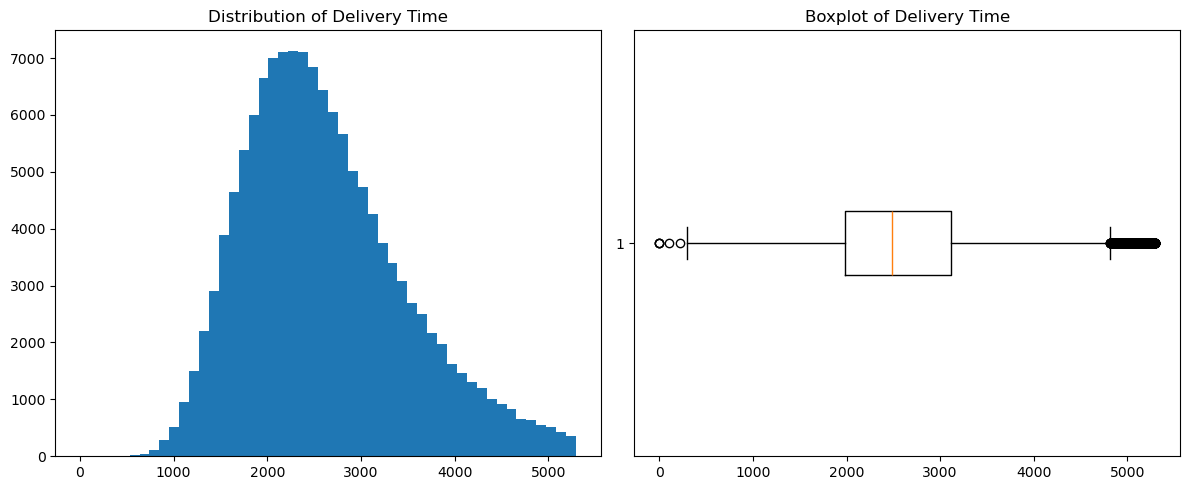

In [3]:
import matplotlib.pyplot as plt
#Hist plot
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.hist(df['delivery_time'],bins=50)
plt.title('Distribution of Delivery Time')
#Box plot
plt.subplot(1,2,2)
plt.boxplot(df['delivery_time'], vert=False)
plt.title('Boxplot of Delivery Time')

plt.tight_layout()
plt.show()

Insights from this plot:
Delivery Time is slightly right-skewed, with most values concentrated between 1985 and 3118 seconds. The median delivery time is around 2487 seconds(41 minutes), indicating a typical delivery duation. A few extreme values on both ends suggest possible data anomalies (very low values) and operational delays (very high values).

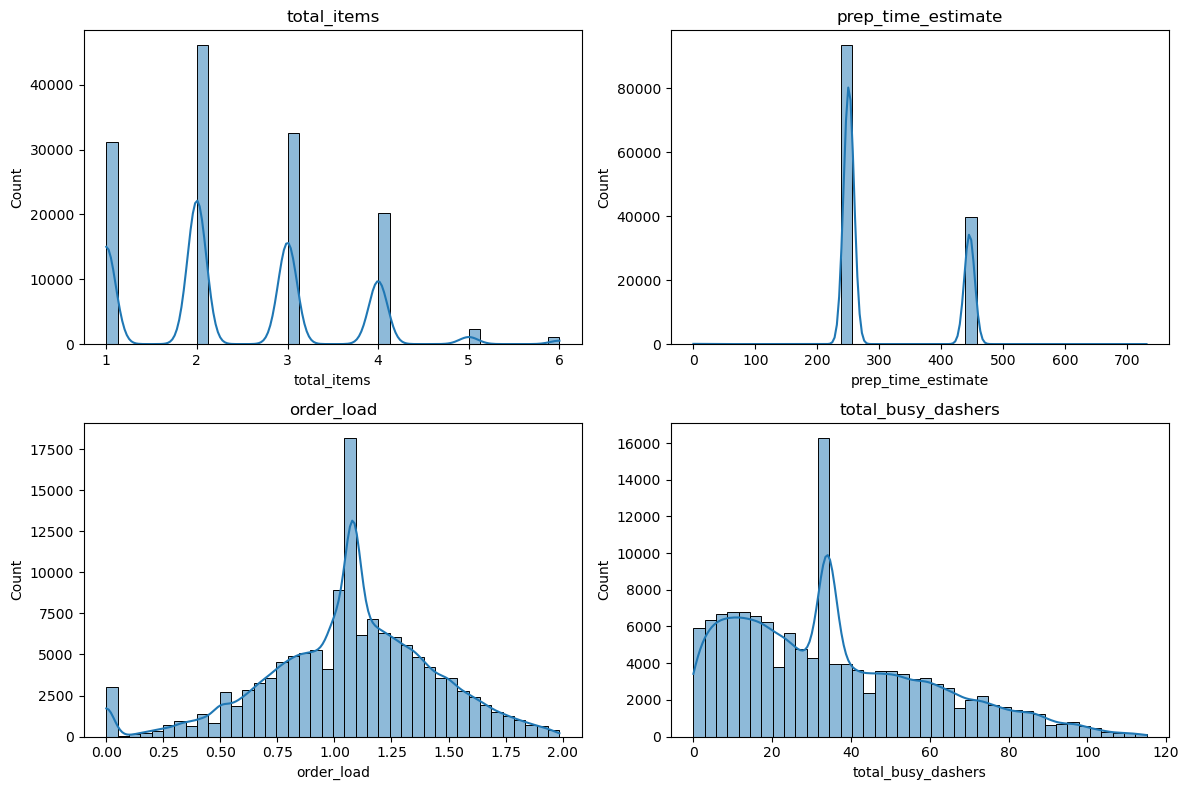

In [4]:
num_cols = ['total_items','prep_time_estimate','order_load','total_busy_dashers']
plt.figure(figsize=(12,8))
for i,col in enumerate(num_cols,1):
    plt.subplot(2,2,i)
    sns.histplot(df[col],bins=40,kde=True)
    plt.title(col)

plt.tight_layout()
plt.show()

Insights from this plot:
1.) Distribution of total_items:
    The number of items per order is concentrated aound 2-3, indicating that most customer place small orders.
    Althrough larger orders exist, they are relatively rare and may contribute to increased preparation and       delivery time.
2.) Distribution of prep_time_estimate:
    Preparation time is mostly concentrated between 250 and 450 seconds, with a slight right skew. This           indicates that most restaurants follow a consistent preparation time, while a few orders require              significantly more time, which can directly impact delivery duration.
3.) Distribution of order_load:
    Order load is generally centered around moderate values, indicating a balanced system most of the time.
    However, the presence of outliers suggests occasional spikes in demand, which may lead to delays in           delivery.
4.) Distribution of total_busy_dashers:
    The number of active dashers typically ranges around 30-50, indicating moderate workforce availability.
    However, variations and higher values suggest fluctuating supply conditions, which may affect delivery        efficiency depending on demand.

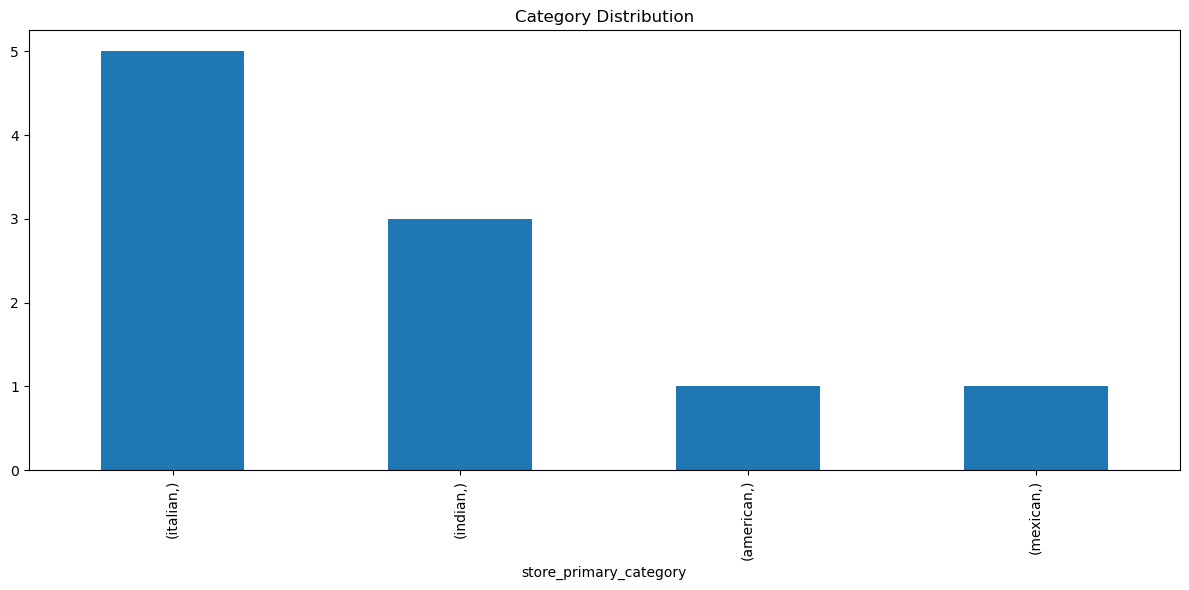

In [5]:
cat_cols = df.select_dtypes(include='object').columns.tolist()
plt.figure(figsize=(12,6))
df[cat_cols].head(10).value_counts().plot(kind='bar')
plt.title('Category Distribution')

plt.tight_layout()
plt.show()

Insights from this plot:
Delivery time varies across store categories, with italain cuisine showing the highest average delivery duration and Mexican cuisine the lowest among the top categories. This suggests that cuisine type may influence delivery time, potentially due to differences in preparation complexity or cooking processes.

Reasoning:
1.) Italian Food:
    1.) Often involves complex preparation(pasta,baking,sauces).
    2.) May require longer cooking time.
2.) Mexican Food:
    1.) Often faster Preparation.
    2.) More assembly-based items.

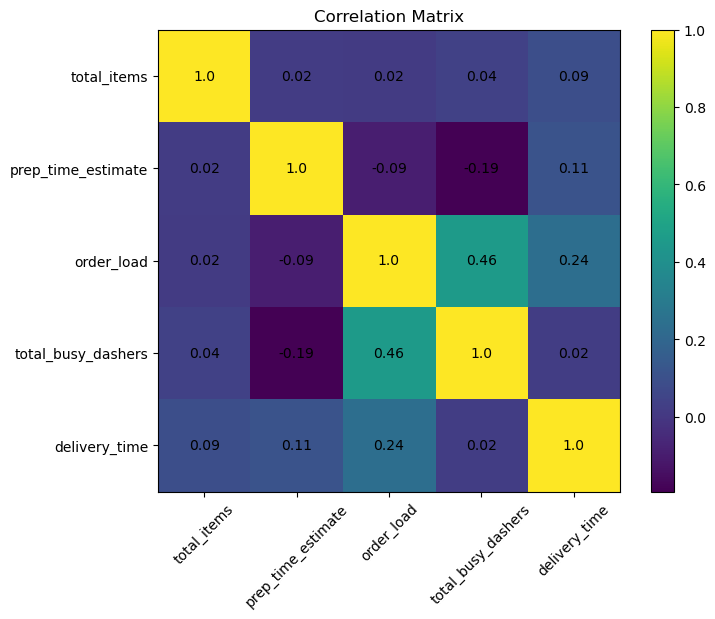

In [6]:
corr = df[num_cols+['delivery_time']].corr()
plt.figure(figsize=(8,6))
plt.imshow(corr,interpolation='nearest')
plt.colorbar()
plt.xticks(range(len(corr.columns)),
           corr.columns,rotation=45)
plt.yticks(range(len(corr.columns)),
           corr.columns)

for i in range(len(corr.columns)):
    for j in range(len(corr.columns)):
        plt.text(j,i,round(corr.iloc[i,j],2),
                           ha = 'center',
        va = 'center', color='black')
plt.title('Correlation Matrix')
plt.show()

Insights from this plot:
1.) As order_load increases, delivery time tends to increase , indicating that higher system demand leads to
slower deliveries i.e., More Orders -> congestion -> delay.
2.) A higher number of available dashers slightly reduces delivery time, suggesting that increased workforce 
improves delivery efficiency i.e., More dashers -> faster delivery.
3.) Preparation time does not show a strong linear correlation  with delivery time in this dataset, which may complex interactions such as order load and system conditions.
4.) There is a moderate positive correlation between order load and number of busy dashers, indicating that as demand increases, more dashers are engaged. However, these increase may not be sufficient to fully offset delivery delays.

In [7]:
#Creating new features for time feature plotting
d2 = pd.read_csv('C:/Users/USER/Desktop/Kaggle/New Data/datasets/historical_data.csv')
d2['created_at'] = pd.to_datetime(d2['created_at'])
df['order_day'] = d2['created_at'].dt.day_name()
df['order_hour'] = d2['created_at'].dt.hour

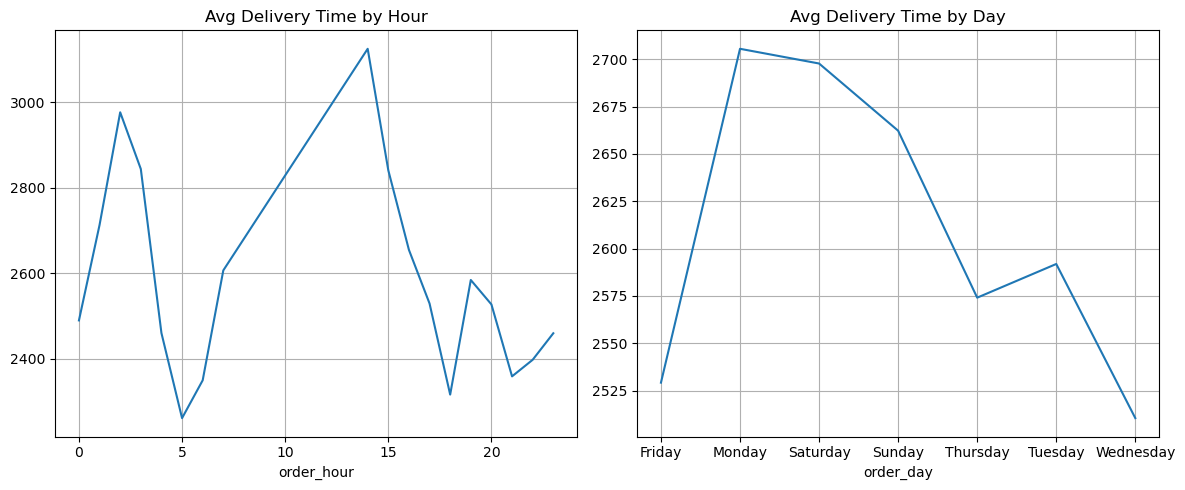

In [8]:
plt.figure(figsize=(12,5))
# Hour vs Delivery Time
plt.subplot(1,2,1)
df.groupby('order_hour')['delivery_time'].mean().plot()
plt.grid(True)
plt.title('Avg Delivery Time by Hour')

# Day vs Delivery Time
plt.subplot(1,2,2)
df.groupby('order_day')['delivery_time'].mean().plot()
plt.title('Avg Delivery Time by Day')

plt.tight_layout()
plt.grid(True)
plt.show()

Insights from this plot:
1.) Hour Based Insight:
    Delivery time is lowest during early morning hours (around 5AM) , likely due to low demand and minimal      system congestion. In contrast, delivery time peaks between 10AM and 3PM, which corresponds to high-demand    periods such as lunch hours, leading to increased order load and potential delays.
  Reasoning:
   1.) 5AM --> Very few Orders --> fast delivery
   2.) 10-3 --> lunch rush --> high demand --> delays
2.) Day Based Insight:
  Delivery time is highest on Mondays, possibly due to increased order volume at the start of the week, while   wednesdays show the lowest delivery time, indicating relatively balanced demand and smoother operations.
  Reasoning:
    1.) Monday --> Backlog/higher demand.
    2.) Wednesday --> Stable Flow.

Business Recommodations:
1.) Increase dashers during peak hours(10-3).
2.) Predit demand spikes using time-based trends.
3.) Optimize restaurant prep time for high-load periods.
4.) Implement dynamic resource allocation.